<a href="https://colab.research.google.com/github/mhsakibb/Sentiment-Analysis/blob/main/Sentiment_Analysis_on_Product_Reviews_(IMDB)_Mosharef_Hossain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis on Product Reviews (IMDB)

In [ ]:
!pip install datasets transformers gensim nltk scikit-learn beautifulsoup4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import warnings

from bs4 import BeautifulSoup
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from gensim.models import Word2Vec

from transformers import AutoTokenizer, AutoModel
import torch

warnings.filterwarnings("ignore")

nltk.download('punkt')

**Load IMDB Dataset**

In [ ]:
imdb = load_dataset("imdb")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

**Convert Dataset to DataFrame**

In [ ]:
train_df = pd.DataFrame(imdb['train'])
test_df = pd.DataFrame(imdb['test'])

train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
test_df.head()

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


In [ ]:
test_df.tail()

,text,label,clean_review
24995,Just got around to seeing Monster Man yesterda...,1,just got around to seeing monster man yesterda...
24996,I got this as part of a competition prize. I w...,1,i got this as part of a competition prize i wa...
24997,I got Monster Man in a box set of three films ...,1,i got monster man in a box set of three films ...
24998,"Five minutes in, i started to feel how naff th...",1,five minutes in i started to feel how naff thi...
24999,I caught this movie on the Sci-Fi channel rece...,1,i caught this movie on the scifi channel recen...


**Text Preprocessing**

In [ ]:
def clean_text(text):

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
train_df['clean_review'] = train_df['text'].apply(clean_text)
test_df['clean_review'] = test_df['text'].apply(clean_text)

**Prepare Features and Labels**

In [ ]:
X_train = train_df['clean_review']
y_train = train_df['label']

X_test = test_df['clean_review']
y_test = test_df['label']

**TF-IDF Vectorization**

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Train TF-IDF Classifier**

In [ ]:
tfidf_model = LogisticRegression(max_iter=1000)

tfidf_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

**Evaluate TF-IDF Model**

In [ ]:
tfidf_preds = tfidf_model.predict(X_test_tfidf)

tfidf_acc = accuracy_score(y_test, tfidf_preds)

print("TF-IDF Accuracy:", tfidf_acc)

print(classification_report(y_test, tfidf_preds))

TF-IDF Accuracy: 0.8758
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.87      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



### WORD2VEC MODEL
**Tokenization**

In [ ]:
train_tokens = [text.split() for text in X_train]
test_tokens = [text.split() for text in X_test]

**Train Word2Vec**

In [ ]:
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

**Create Sentence Embeddings**

In [ ]:
def document_vector(doc):

    words = [word for word in doc if word in w2v_model.wv]

    if len(words) == 0:
        return np.zeros(100)

    return np.mean(w2v_model.wv[words], axis=0)

In [ ]:
X_train_w2v = np.array([document_vector(doc) for doc in train_tokens])
X_test_w2v = np.array([document_vector(doc) for doc in test_tokens])

**Train Word2Vec Classifier**

In [ ]:
w2v_classifier = LogisticRegression(max_iter=1000)

w2v_classifier.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000)

**Evaluate Word2Vec**

In [ ]:
w2v_preds = w2v_classifier.predict(X_test_w2v)

w2v_acc = accuracy_score(y_test, w2v_preds)

print("Word2Vec Accuracy:", w2v_acc)

print(classification_report(y_test, w2v_preds))

Word2Vec Accuracy: 0.8072
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     12500
           1       0.81      0.81      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



### BERT EMBEDDINGS
**Load BERT Model**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

bert_model = AutoModel.from_pretrained('distilbert-base-uncased')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Create BERT Embedding Function**

In [ ]:
def get_bert_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze().numpy()

**Reduce Dataset Size**

In [ ]:
from sklearn.utils import shuffle

sample_size = 3000

# Shuffle training data
X_train_shuffled, y_train_shuffled = shuffle(
    X_train,
    y_train,
    random_state=42
)

# Shuffle test data
X_test_shuffled, y_test_shuffled = shuffle(
    X_test,
    y_test,
    random_state=42
)

# Take samples after shuffling
X_train_small = X_train_shuffled[:sample_size]
y_train_small = y_train_shuffled[:sample_size]

X_test_small = X_test_shuffled[:1000]
y_test_small = y_test_shuffled[:1000]

**Generate BERT Embeddings**

In [ ]:
X_train_bert = np.array([
    get_bert_embedding(text)
    for text in X_train_small
])

X_test_bert = np.array([
    get_bert_embedding(text)
    for text in X_test_small
])

**Train BERT Classifier**

In [ ]:
bert_classifier = LogisticRegression(max_iter=1000)

bert_classifier.fit(X_train_bert, y_train_small)

LogisticRegression(max_iter=1000)

In [ ]:
print(y_train_small.value_counts())

label
0    1555
1    1445
Name: count, dtype: int64


**Evaluate BERT Model**

In [ ]:
bert_preds = bert_classifier.predict(X_test_bert)

bert_acc = accuracy_score(y_test_small, bert_preds)

print("BERT Accuracy:", bert_acc)

print(classification_report(y_test_small, bert_preds))

BERT Accuracy: 0.813
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       511
           1       0.82      0.79      0.80       489

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



**Create Comparison Table**

In [ ]:
results = pd.DataFrame({
    'Method': ['TF-IDF', 'Word2Vec', 'BERT'],
    'Accuracy': [
        tfidf_acc,
        w2v_acc,
        bert_acc
    ]
})

results

,Method,Accuracy
0,TF-IDF,0.8758
1,Word2Vec,0.8072
2,BERT,0.8130


**Add Precision, Recall, F1**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Method': ['TF-IDF', 'Word2Vec', 'BERT'],

    'Accuracy': [
        tfidf_acc,
        w2v_acc,
        bert_acc
    ],

    'Precision': [
        precision_score(y_test, tfidf_preds),
        precision_score(y_test, w2v_preds),
        precision_score(y_test_small, bert_preds)
    ],

    'Recall': [
        recall_score(y_test, tfidf_preds),
        recall_score(y_test, w2v_preds),
        recall_score(y_test_small, bert_preds)
    ],

    'F1-Score': [
        f1_score(y_test, tfidf_preds),
        f1_score(y_test, w2v_preds),
        f1_score(y_test_small, bert_preds)
    ]
})

comparison

,Method,Accuracy,Precision,Recall,F1-Score
0,TF-IDF,0.8758,0.871432,0.881680,0.876526
1,Word2Vec,0.8072,0.806709,0.808000,0.807354
2,BERT,0.8130,0.824034,0.785276,0.804188


# Comarison Visualization

In [ ]:
import matplotlib.pyplot as plt

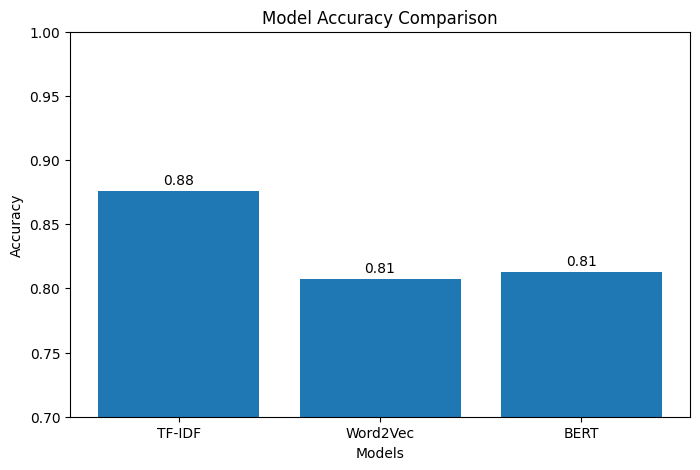

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Method'],
    comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.ylim(0.7, 1.0)

for i, value in enumerate(comparison['Accuracy']):
    plt.text(i, value + 0.005, f"{value:.2f}", ha='center')

plt.show()

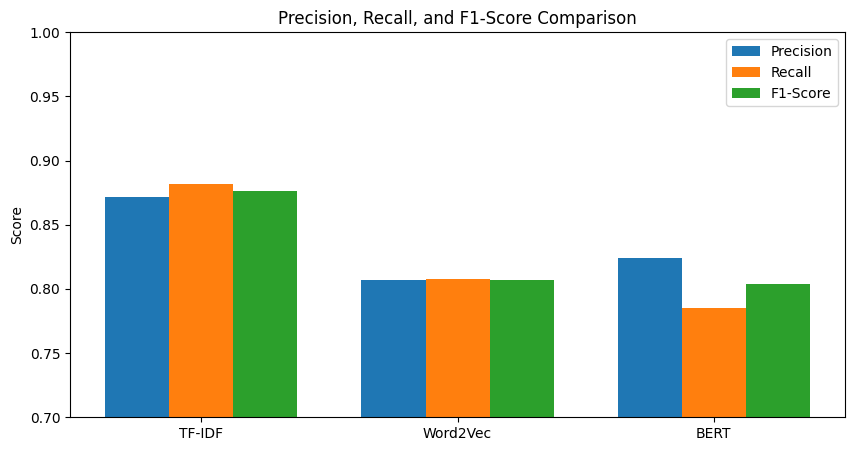

In [ ]:
metrics = ['Precision', 'Recall', 'F1-Score']

x = np.arange(len(comparison['Method']))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, comparison['Precision'], width, label='Precision')
plt.bar(x, comparison['Recall'], width, label='Recall')
plt.bar(x + width, comparison['F1-Score'], width, label='F1-Score')

plt.xticks(x, comparison['Method'])

plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score Comparison')

plt.ylim(0.7, 1.0)

plt.legend()

plt.show()

# Analysis
TF-IDF achieved the best performance in this experiment in terms of accuracy and F1-score, showing that simple statistical methods can be very strong for sentiment classification on the IMDB dataset.

Word2Vec showed lower performance compared to TF-IDF, mainly because averaging word embeddings loses important sentence-level context and word order information.

BERT did not outperform TF-IDF in this setup, which may be due to limited sample size, use of mean pooling over embeddings, and lack of full fine-tuning.

Despite this, BERT still showed competitive results and slightly better generalization than Word2Vec in some cases.
TF-IDF was computationally efficient, fast to train, and required less processing power compared to deep learning-based approaches.

Word2Vec required training word embeddings and additional preprocessing steps, making it moderately resource-intensive.

BERT embeddings were the most computationally expensive to generate, especially in Google Colab without GPU optimization or fine-tuning.

All models performed relatively well on clearly positive or negative reviews.

Misclassifications mostly occurred in complex sentences containing negation, sarcasm, or mixed sentiment.

Overall, there is a clear trade-off between simplicity, computational cost, and contextual understanding capability among the three approaches.